In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('..\..\Data\df_with_2regimes.csv')
df['date'] = pd.to_datetime(df['date'])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3518 entries, 0 to 3517
Data columns (total 37 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   date                                        3518 non-null   datetime64[ns]
 1   log_return                                  3518 non-null   float64       
 2   realized_variance                           3518 non-null   float64       
 3   realized_volatility                         3518 non-null   float64       
 4   gtrend_pct_change                           3518 non-null   float64       
 5   blockchain_diff_log_n_transactions          3518 non-null   float64       
 6   blockchain_diff_log_transaction_fee_usd     3518 non-null   float64       
 7   blockchain_diff_log_n_unique_addresses      3518 non-null   float64       
 8   blockchain_diff_log_transaction_volume_usd  3518 non-null   float64       
 9   log_volu

In [4]:
# lag 1,2 andd 3 of realized volatility
df['rv_lag1'] = df['realized_variance'].shift(1)
df['rv_lag2'] = df['realized_variance'].shift(2)
df['rv_lag3'] = df['realized_variance'].shift(3)

# rolling mean of realized volatility over the past 7 & 30 days
df['rv_rolling_mean_7'] = df['realized_variance'].rolling(window=7).mean()
df['rv_rolling_mean_30'] = df['realized_variance'].rolling(window=30).mean() 

df['target'] = df['realized_variance'].shift(-1)

# Clipping: Floor (5-day moving average of past targets)
df['var_floor_5'] = df['realized_variance'].rolling(5).mean()

# drop rows with NaN values (due to lag and rolling mean)
df = df.dropna().reset_index(drop=True)
df = df.iloc[364:].reset_index(drop=True)
df.head(30)
df.info()
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3124 entries, 0 to 3123
Data columns (total 43 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   date                                        3124 non-null   datetime64[ns]
 1   log_return                                  3124 non-null   float64       
 2   realized_variance                           3124 non-null   float64       
 3   realized_volatility                         3124 non-null   float64       
 4   gtrend_pct_change                           3124 non-null   float64       
 5   blockchain_diff_log_n_transactions          3124 non-null   float64       
 6   blockchain_diff_log_transaction_fee_usd     3124 non-null   float64       
 7   blockchain_diff_log_n_unique_addresses      3124 non-null   float64       
 8   blockchain_diff_log_transaction_volume_usd  3124 non-null   float64       
 9   log_volu

In [5]:
# drop columns
exclude_cols = ['p_sigma', 'p_r', 'p_d', 'regime', 'regime_id', 'date', 'realized_volatility', 'target', 'var_floor_5']

all_features = [col for col in df.columns if col not in exclude_cols]
print(f"Total features being used: {len(all_features)}") 

Total features being used: 34


In [6]:
train_end = 1874
val_end = 2655  # This is also where the rolling window starts (test_start_idx)

train_df = df.iloc[0:train_end].copy()
eval_df  = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

for name, d in {"Train": train_df, "Val": eval_df, "Test": test_df}.items():
    print(f"{name:5} | Rows: {len(d):4} | Indices: {d.index[0]}-{d.index[-1]}")

# Global Upper Bound from Training Data
upper_bound = train_df['target'].quantile(0.995)

Train | Rows: 1874 | Indices: 0-1873
Val   | Rows:  781 | Indices: 1874-2654
Test  | Rows:  469 | Indices: 2655-3123


In [7]:
X_tune = df.iloc[:val_end][all_features]
y_tune = df.iloc[:val_end]['target']

scaler_tune = StandardScaler()
X_tune_scaled = scaler_tune.fit_transform(X_tune)

In [8]:
param_grid = {
    'C': [0.1, 1, 10, 50],
    'epsilon': [1e-4, 1e-3, 1e-2],
    'gamma': ['scale', 'auto', 0.1, 0.01] 
}

# Note: We use SVR() which defaults to 'rbf' kernel
svr_rbf_base = SVR(kernel='rbf', max_iter=50000)

grid_search = GridSearchCV(
    estimator=svr_rbf_base,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5
)

grid_search.fit(X_tune_scaled, y_tune)

best_params = grid_search.best_params_
print(f"Best Params: {best_params}")

C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\tklia\OneDrive\Documents\DSE4211\Project\SVR-L Code\vol_project\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-pro

Best Params: {'C': 0.1, 'epsilon': 0.0001, 'gamma': 0.01}


In [9]:
results = []
window_size = 365 

for t in range(val_end, len(df)):
    # 1. Windows
    train_window = df.iloc[t - window_size : t]
    test_row = df.iloc[[t]]
    
    X_train_roll = train_window[all_features]
    y_train_roll = train_window['target']
    X_test_now = test_row[all_features]
    y_actual = test_row['target'].values[0]
    
    # 2. Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_roll)
    X_test_scaled = scaler.transform(X_test_now)
    
    # 3. Model Training (RBF)
    model = SVR(
        kernel='rbf',
        C=best_params['C'],
        epsilon=best_params['epsilon'],
        gamma=best_params['gamma'],
        max_iter=50000
    )
    model.fit(X_train_scaled, y_train_roll)
    
    # 4. Predict and Clip
    raw_pred = model.predict(X_test_scaled)[0]
    
    # Apply Floor (5-day MA) and Global Upper Bound
    floor_val = test_row['var_floor_5'].values[0]
    final_pred = np.clip(raw_pred, max(1e-7, floor_val), upper_bound)
    
    results.append({
        "date": t, # Or use a date column if available
        "actual": y_actual,
        "predicted": final_pred
    })

results_df = pd.DataFrame(results)

In [10]:
def qlike(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)
    
    # Calculation: (y / y_hat) - log(y / y_hat) - 1
    # We add 1e-10 to prevent division by zero errors
    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - 
                         np.log(test_actuals / (test_preds + 1e-10)) - 1)
    return test_qlike

# --- 3. EXECUTE EVALUATION ---
# Using 'results_df' which you created in your loop
y_true = results_df['actual']
y_pred = results_df['predicted']

rmse_roll = np.sqrt(mean_squared_error(y_true, y_pred))
mae_roll = mean_absolute_error(y_true, y_pred)
qlike_val = qlike(y_true, y_pred)

print("\n" + "="*40)
print("SVR-RBF FINAL PERFORMANCE")
print("="*40)
print(f"RMSE:  {rmse_roll:.10f}")
print(f"MAE:   {mae_roll:.10f}")
print(f"QLIKE: {qlike_val:.10f}")
print(f"Forecast Count: {len(results_df)}")
print("="*40)


SVR-RBF FINAL PERFORMANCE
RMSE:  0.0007260172
MAE:   0.0005147521
QLIKE: 0.4874279035
Forecast Count: 469


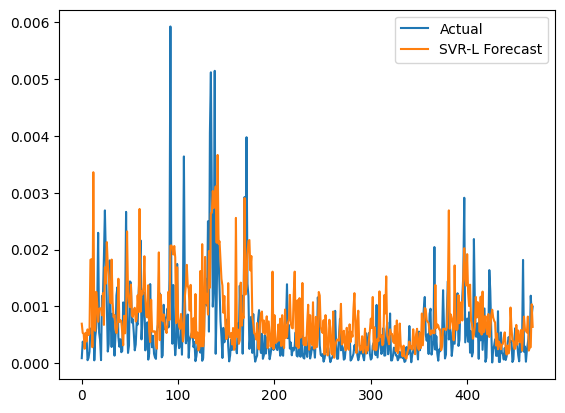

In [11]:
# Plotting
plt.plot(results_df['actual'], label="Actual")
plt.plot(results_df['predicted'], label="SVR-L Forecast")
plt.legend()
plt.show()